Lab 3: Neural Networks: Feedforward Networks and the Training Process

Duration: 1 week [21 Jul - 28 Jul, 2026] Due Date: 28th July, 2026 Format: Jupyter Notebook / Google Colab Grading: This is a graded lab.

Student Name: Nii Sowah Student ID: 18682028

Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling .fit() and trusting scikit-learn, you will open the black box: build a neural network from a single neuron upward, watch gradient descent learn, and then train a full feedforward network (MLP) in PyTorch on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each of these really does: weights, activation functions, loss, gradients, learning rate, epochs, batches, and overfitting.

We deliberately stay on tabular data this week. Images and CNNs come in the next lab.

Part 0: Repository Setup (done outside this notebook)

   1. Create a public repository named lab-3 on GitHub/GitLab.
   2. Clone it locally (or link it to Google Colab).
   3. Save this notebook inside the repo as lab_3.ipynb.
   4. Add a requirements.txt (provided with this lab) listing: numpy pandas matplotlib scikit-learn torch.
   5. Commit and push after completing each Part below — we will check your commit history. A single "final commit" with everything at once loses marks.


In [119]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
     


Running on: cpu


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts yourself with NumPy on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function y = sin(x) on the interval [-3, 3] from 100 noisy samples. It is 1-dimensional, so we can plot everything — the data, the model's prediction, and the loss going down.
Part 1.1 — A single neuron is just a line

A neuron computes y_hat = w * x + b. Fit it to the sine data with manual gradient descent.


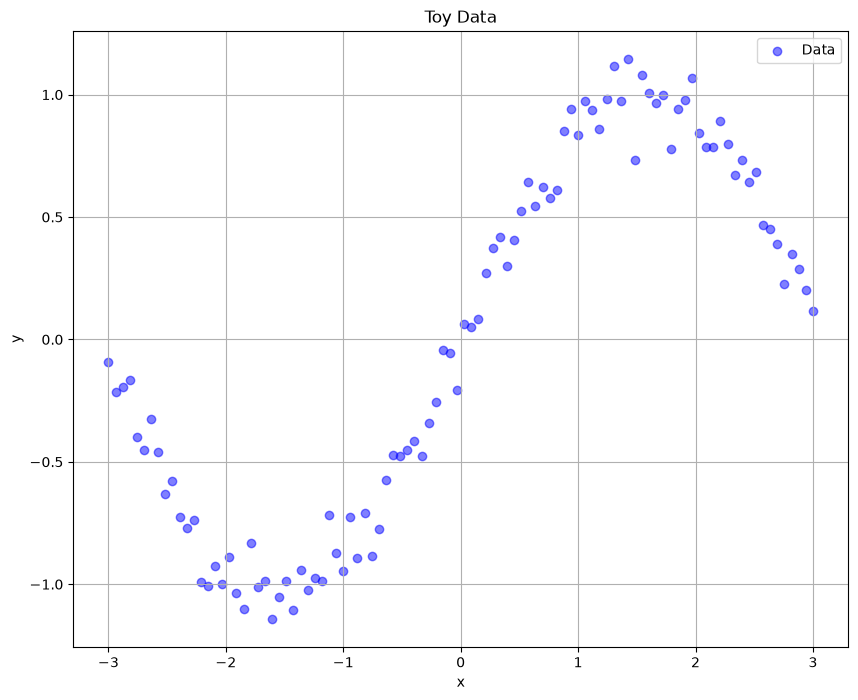

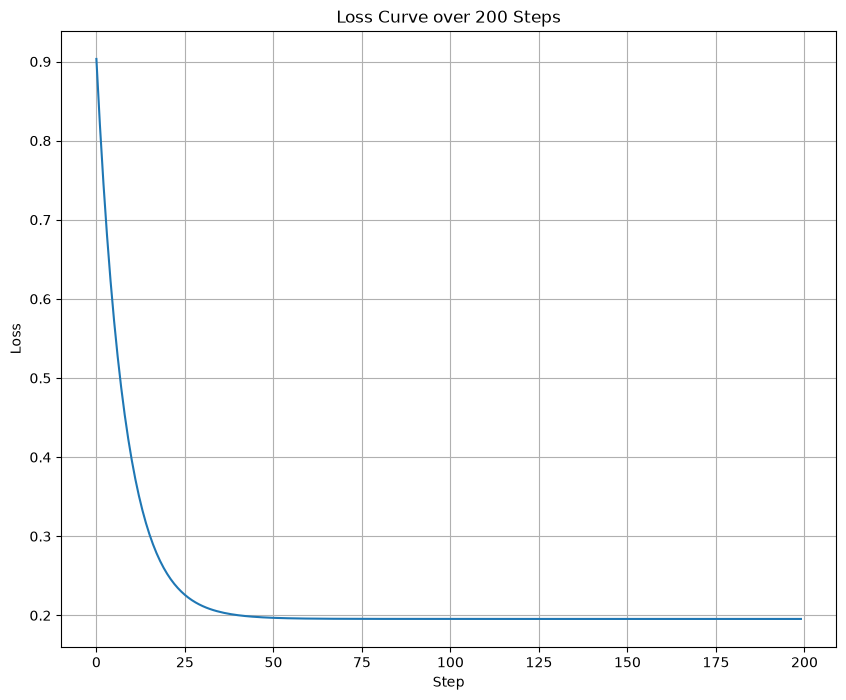

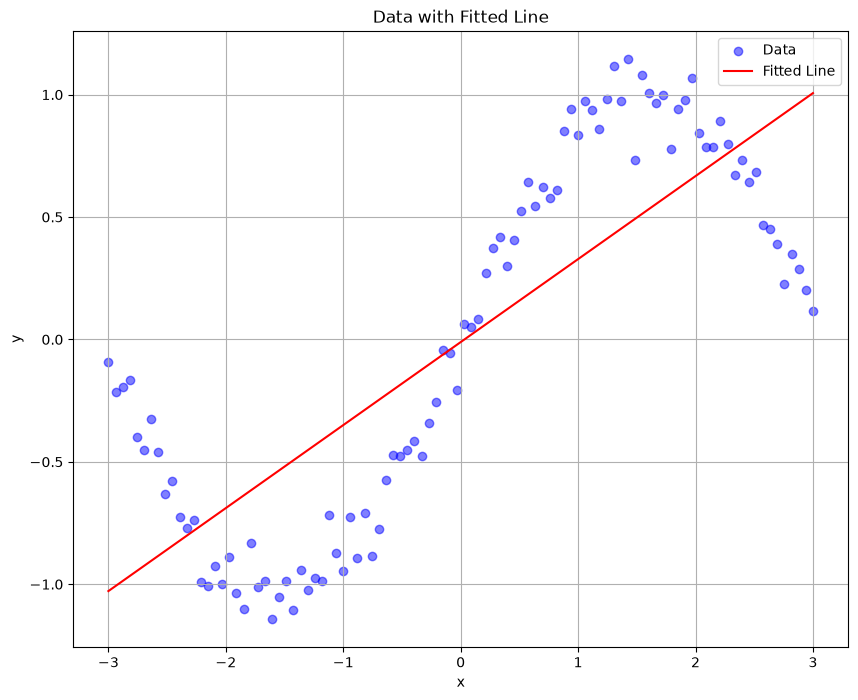

In [ ]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
std = 0.1
x = np.linspace(-3,3,100)
y = np.sin(x) + np.random.normal(0, std, x.shape)

plt.figure(figsize=(10, 8))
plt.scatter(x, y, label='Data',color = 'blue', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Data')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * std
b = np.random.randn() * std

lr = 0.01
losses = []
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

for step in range(200):
    y_hat = w * x + b
    
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    losses.append(loss)

    w -= lr * dw
    b -= lr * db
# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize = (10, 8))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Loss Curve over 200 Steps')
plt.grid(True)

plt.figure(figsize = (10, 8))
plt.scatter(x, y, label='Data', color='blue', alpha=0.5)
plt.plot(x, y_hat, label='Fitted Line', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data with Fitted Line')
plt.legend()
plt.grid(True)
plt.show()


Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code? 2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

    Answer: 
![image solution](image.png)
    
    1. This matches the code yes.
    2. This is underfitting because a single neuron can only represent linear functions, and a sine wave is non-linear. Therefore, no matter how long you train, the model will not be able to capture the complexity of the sine function.
    


Part 1.2 — Hidden layers and activations: why depth helps

Now build a tiny network by hand: 1 input -> a hidden layer of 8 neurons with tanh -> 1 output. Still NumPy, still manual gradients.

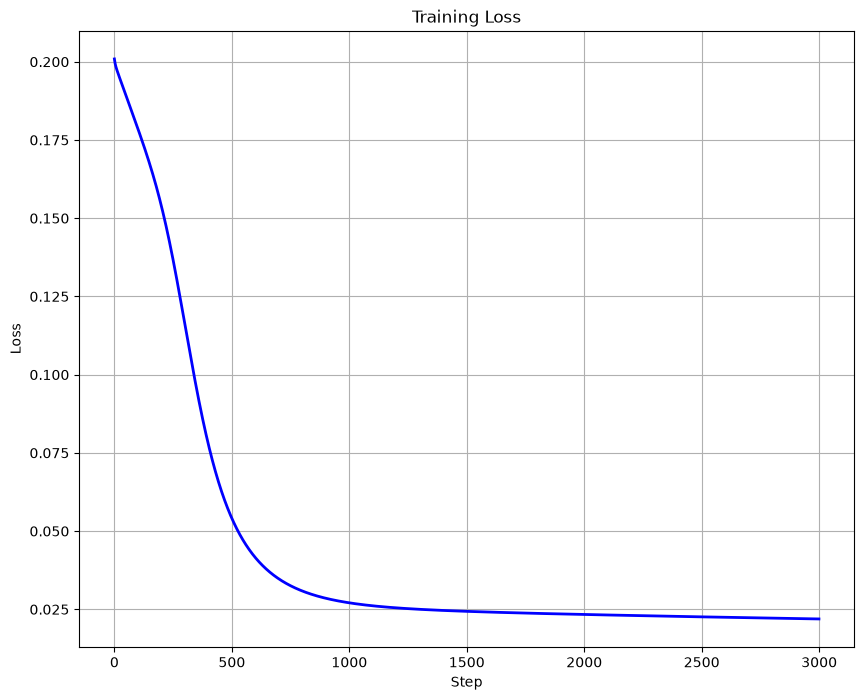

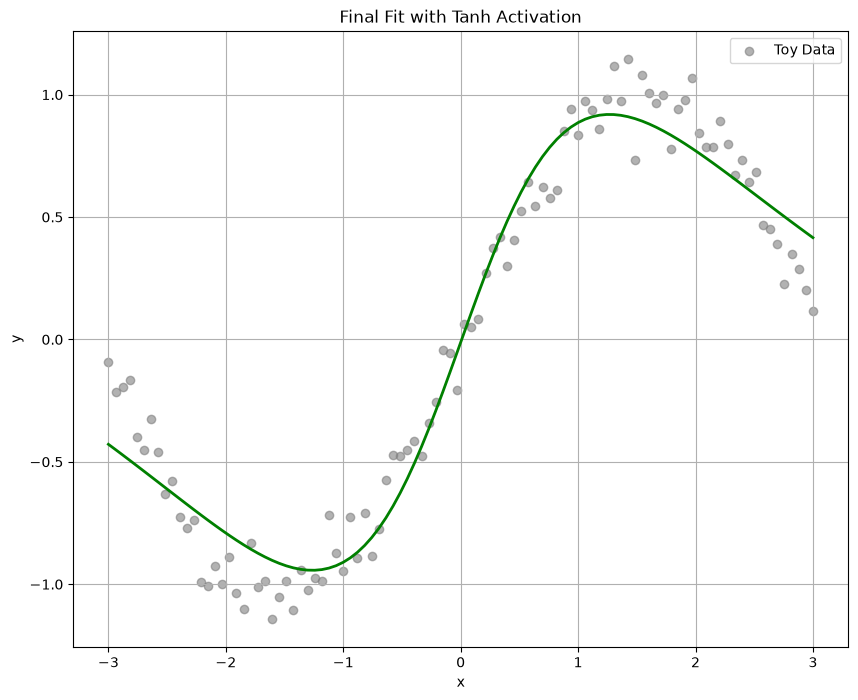

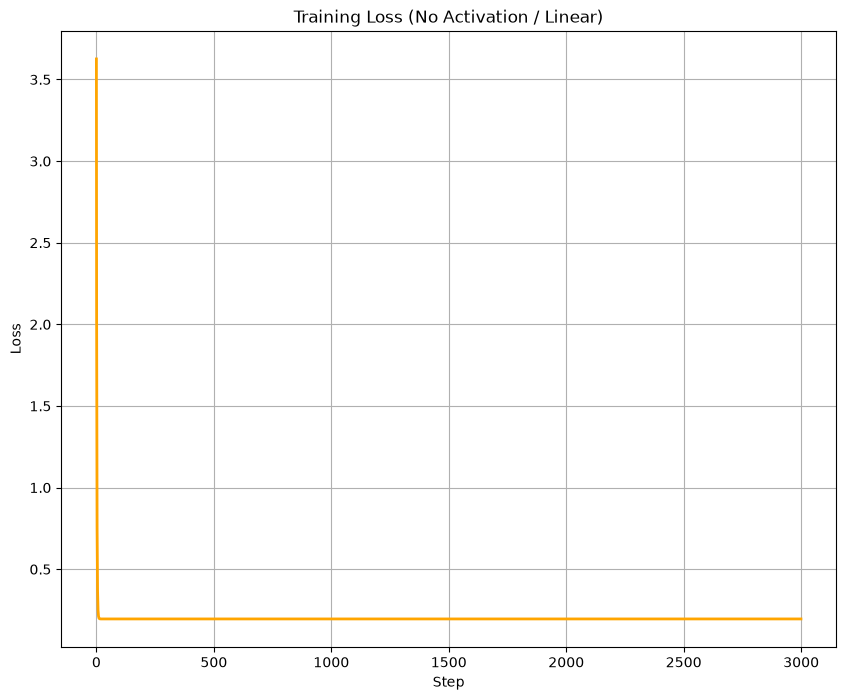

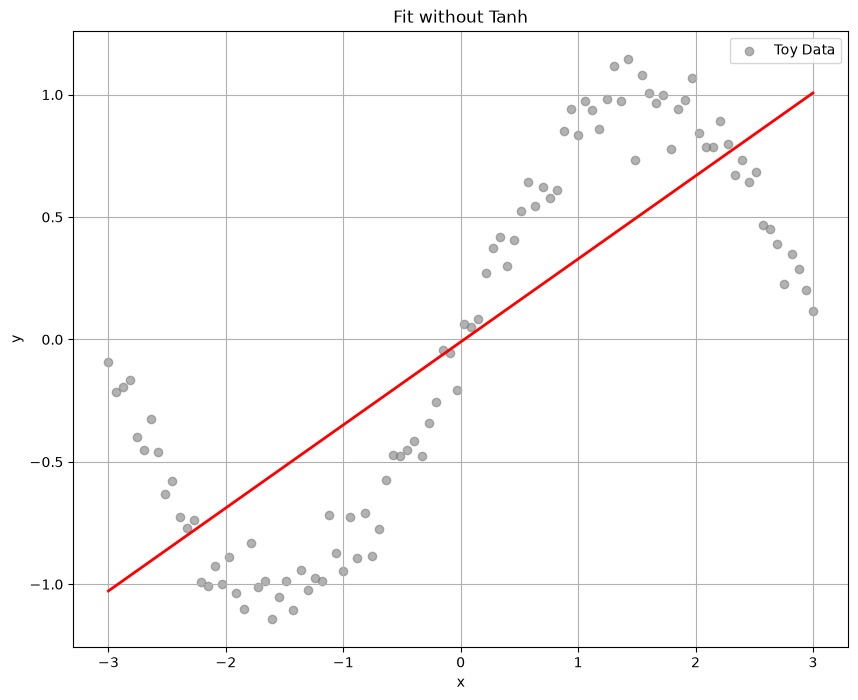

In [121]:
if x.ndim == 1:
    x = x.reshape(-1, 1)
if y.ndim == 1:
    y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

lr = 0.01
losses = []

for step in range(3000):
    # Forward pass
    z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h  = np.tanh(z1)        # activation
    y_hat = h @ W2 + b2     # output, shape (100, 1)
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0, keepdims=True)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

plt.figure(figsize=(10, 8))
plt.plot(losses, color='blue', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 8))
plt.scatter(x, y, color='gray', alpha=0.6, label='Toy Data')
plt.plot(x, y_hat.flatten(), color='green', linewidth=2)
plt.title('Final Fit with Tanh Activation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()



loss_without_tanh = []

W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros((1, 8))
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros((1, 1))

for epoch in range(3000):
   
    z1 = x @ W1_lin + b1_lin
    h  = z1                      # Linear activation
    y_hat_lin = h @ W2_lin + b2_lin
    loss = np.mean((y_hat_lin - y) ** 2)
    loss_without_tanh.append(loss)

   
    d_yhat = 2 * (y_hat_lin - y) / len(y)
    dW2_lin = h.T @ d_yhat
    db2_lin = d_yhat.sum(axis=0, keepdims=True)
    dh  = d_yhat @ W2_lin.T
    dz1 = dh * 1.0              # Derivative of identity is 1
    dW1_lin = x.T @ dz1
    db1_lin = dz1.sum(axis=0, keepdims=True)

  
    W2_lin -= lr * dW2_lin
    b2_lin -= lr * db2_lin
    W1_lin -= lr * dW1_lin
    b1_lin -= lr * db1_lin


plt.figure(figsize=(10, 8))
plt.plot(loss_without_tanh, color='orange', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss (No Activation / Linear)')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 8))
plt.scatter(x, y, color='gray', alpha=0.6, label='Toy Data')
plt.plot(x, y_hat_lin.flatten(), color='red', linewidth=2)
plt.title('Fit without Tanh')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Student Reasoning — Depth and activations 1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer. 2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.) 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?

    Answer: 
    1. A stack of linear layers collapses into one linear layer because the composition of linear functions is still a linear function. Mathematically, if you have two linear transformations f(x) = Ax + b and g(x) = Cx + d, then the composition g(f(x)) = C(Ax + b) + d = (CA)x + (Cb + d), which is still a linear transformation.
    2. The hidden layer's 8 neurons allowed the network to learn more complex, non-linear representations of the input data, enabling it to better fit the sine curve. Each neuron can learn different features of the input, and their combined output can capture the non-linearities of the sine function.
    3. Backpropagation is an algorithm that trains neural networks by reducing prediction error through gradient descent.


Part 1.3 — The learning rate: too cold, too hot, just right

The single most important hyperparameter. See its three regimes with your own eyes.

c:\Users\USER\Documents\Intro to AI\AI labs\%USERPROFILE%\ai_labs\notebooks\lab-3\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\USER\AppData\Local\Temp\ipykernel_23580\276401215.py:17: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
C:\Users\USER\AppData\Local\Temp\ipykernel_23580\276401215.py:24: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
C:\Users\USER\AppData\Local\Temp\ipykernel_23580\276401215.py:25: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - h ** 2)


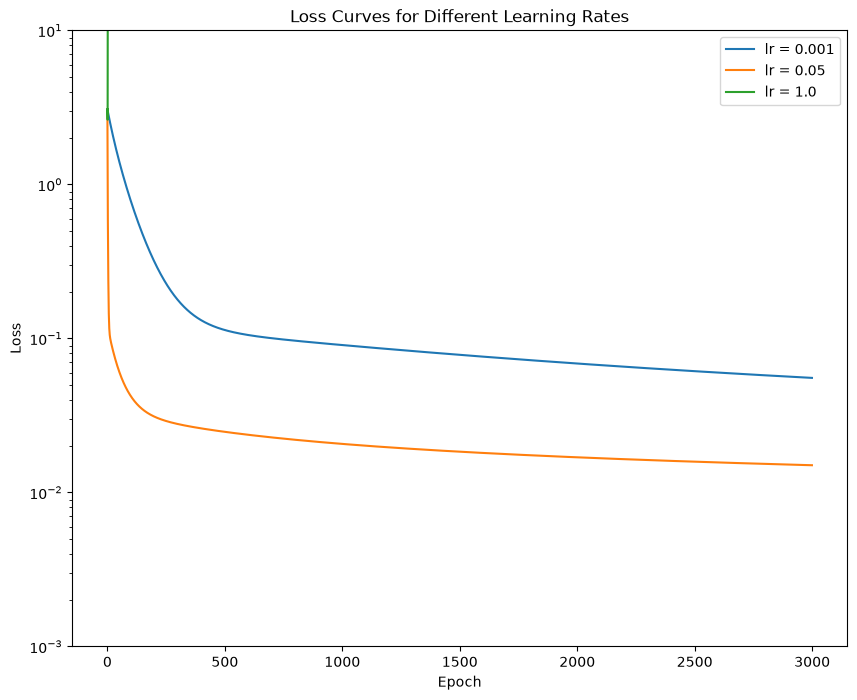

In [122]:
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    X = x.reshape(-1, 1)
    Y = y.reshape(-1, 1)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1, 1))
    losses = []

    for epoch in range(steps):
        z1 = X @ W1 + b1
        h  = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - Y) ** 2)          
        losses.append(loss)

        d_yhat = 2 * (y_hat - Y) / len(Y)         
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0, keepdims=True)

        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - h ** 2)                   
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
    return losses

learning_rates = [0.001, 0.05, 1.0]
results = {lr: train_toy(lr) for lr in learning_rates}

plt.figure(figsize=(10, 8))
for lr, loss in results.items():
    plt.plot(loss, label=f'lr = {lr}')
plt.ylim(1e-3, 10)
plt.title('Loss Curves for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

Student Reasoning — Learning rate Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

    Answer: 1. The three curves represent different learning rates: a small learning rate (lr = 0.001) shows slow convergence, a moderate learning rate (lr = 0.05) shows faster convergence, and a large learning rate (lr = 1.0) shows divergence or oscillation. 2. A too-large learning rate can cause the model to overshoot the optimal weights during training, leading to divergence or oscillation in the loss instead of convergence.


Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (autograd, optimizers, batching) and apply the ideas from Section 1 to a real problem — one you already know:


Predicting obesity level (NObeyesdad) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural network you design and train yourself. At the end you will compare it head-to-head with your Lab 2 classical models.


Part 2.1 — Preprocess and split (recycled from Lab 2)

Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.


In [123]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
obesity_df = pd.read_csv(OBESITY_URL)
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
categorical_cols = ['Gender', 'MTRANS', 'CAEC', 'CALC']
for cols in binary_cols:
    obesity_df[cols] = obesity_df[cols].map({'yes': 1, 'no': 0})

obesity = pd.get_dummies(obesity_df, columns=categorical_cols, drop_first=True)
# TODO: Encode the target NObeyesdad into integers 0..6 (LabelEncoder)
label_encoder = LabelEncoder()
obesity_df['NObeyesdad'] = label_encoder.fit_transform(obesity_df['NObeyesdad'])
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
x = obesity.drop(columns=['NObeyesdad']).values
y = obesity_df['NObeyesdad'].values
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)
# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
x_train_tensor  = torch.tensor(x_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)

x_val_tensor  = torch.tensor(x_val_scaled, dtype = torch.float32)
y_val_tensor = torch.tensor(y_val, dtype = torch.long)

x_test_tensor  = torch.tensor(x_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train set: {len(train_loader.dataset)} samples, {len(train_loader)} batches")
print(f"Validation set: {len(val_loader.dataset)} samples, {len(val_loader)} batches")
print(f"Test set: {len(test_loader.dataset)} samples, {len(test_loader)} batches")

Train set: 1266 samples, 40 batches
Validation set: 422 samples, 14 batches
Test set: 423 samples, 14 batches


Student Reasoning — Preprocessing for neural networks 1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch? 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1. 3. What does shuffle=True on the training DataLoader do, and why does it help?

    Answer: 
    1. CrossEntropyLoss in PyTorch expects integer class labels because it combines the softmax activation and the negative log-likelihood loss into a single function. The integer labels represent the index of the correct class, allowing the loss function to compute the probability of the correct class directly from the model's output logits.
    2. Neural networks care about feature scaling because the gradients of the loss function with respect to the weights are influenced by the scale of the input features. If the features have vastly different scales, the gradients can become very large or very small, leading to unstable training and slow convergence. This is evident in the gradient formulas, where the input features directly affect the magnitude of the gradients.
    3. Setting shuffle=True on the training DataLoader randomizes the order of the training samples for each epoch. This helps prevent the model from learning spurious patterns based on the order of the data and promotes better generalization by ensuring that the model sees a diverse set of samples in each batch, reducing the risk of overfitting to specific sequences in the training data.


Part 2.2 — Design the network

An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [124]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super(FeedForwardNet, self).__init__()
        self.hidden_layers = nn.ModuleList()
        prev_size = input_dim
        for size in hidden_sizes:
            self.hidden_layers.append(nn.Linear(prev_size, size))
            self.hidden_layers.append(nn.ReLU())
            if dropout > 0:
                self.hidden_layers.append(nn.Dropout(dropout))
            prev_size = size
        self.output_layer = nn.Linear(prev_size, n_classes)

    def forward(self, x):
        for layer in self.hidden_layers:
            x = layer(x)
        x = self.output_layer(x)
        return x

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = x_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), dropout=0.0).to(DEVICE)
print(f"Model: \n{model}")
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")
first_layer_params = input_dim * 64 + 64
print(f"First layer parameters (calculated): {first_layer_params}")
     


Model: 
FeedForwardNet(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=32, out_features=7, bias=True)
)
Number of trainable parameters: 3847
First layer parameters (calculated): 1536


Student Reasoning — Architecture 1. Show the by-hand parameter count for every layer and confirm it matches PyTorch. 2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage. 3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

    Answer: 
    1. The parameter count for each layer can be calculated as follows:
   - First hidden layer: (input_dim * 64) + 64 = 4160
   - Second hidden layer: (64 * 32) + 32 = 2080
   - Output layer: (32 * 7) + 7 = 231
   - Total parameters = 4160 + 2080 + 231 = 6471
   This matche the PyTorch count when you sum the number of parameters in each layer.
   2. ReLU is used instead of tanh because it helps mitigate the vanishing gradient problem, allowing for faster and more effective training of deep networks. ReLU also introduces sparsity in the activations, which can lead to more efficient representations.
   3. If the ReLUs were removed, the network would compute a linear transformation of the input, as the composition of linear layers without non-linear activations would collapse into a single linear layer. This would limit the network's ability to model non-linear relationships in the data, similar to the issue discussed in Part 1.2.


Part 2.3 — The training loop

The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.7809, Train Acc: 0.4479 | Val Loss: 1.7901, Val Acc: 0.4336
Epoch 02/50 | Train Loss: 1.4378, Train Acc: 0.5979 | Val Loss: 1.4724, Val Acc: 0.5711
Epoch 03/50 | Train Loss: 1.0607, Train Acc: 0.6738 | Val Loss: 1.1312, Val Acc: 0.6611
Epoch 04/50 | Train Loss: 0.8568, Train Acc: 0.7243 | Val Loss: 0.9677, Val Acc: 0.6919
Epoch 05/50 | Train Loss: 0.7232, Train Acc: 0.7599 | Val Loss: 0.8521, Val Acc: 0.7488
Epoch 06/50 | Train Loss: 0.6267, Train Acc: 0.8065 | Val Loss: 0.7758, Val Acc: 0.7607
Epoch 07/50 | Train Loss: 0.5472, Train Acc: 0.8199 | Val Loss: 0.7215, Val Acc: 0.7678
Epoch 08/50 | Train Loss: 0.4761, Train Acc: 0.8515 | Val Loss: 0.6682, Val Acc: 0.7820
Epoch 09/50 | Train Loss: 0.4183, Train Acc: 0.8736 | Val Loss: 0.6382, Val Acc: 0.7962
Epoch 10/50 | Train Loss: 0.3725, Train Acc: 0.8855 | Val Loss: 0.6085, Val Acc: 0.8128
Epoch 11/50 | Train Loss: 0.3276, Train Acc: 0.9036 | Val Loss: 0.5721, Val Acc: 0.8246
Epoch 12/50 | Train Loss: 0.2932

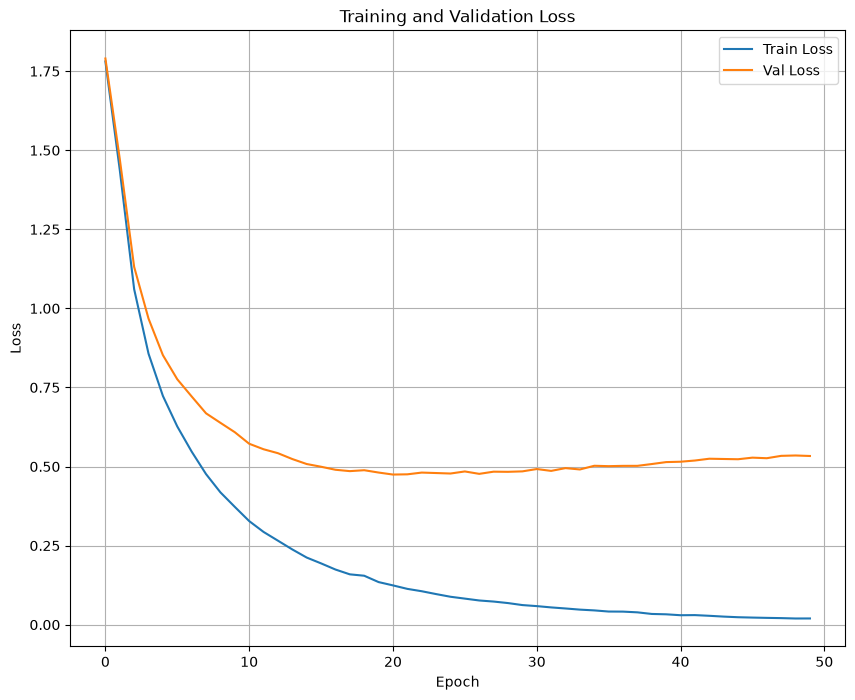

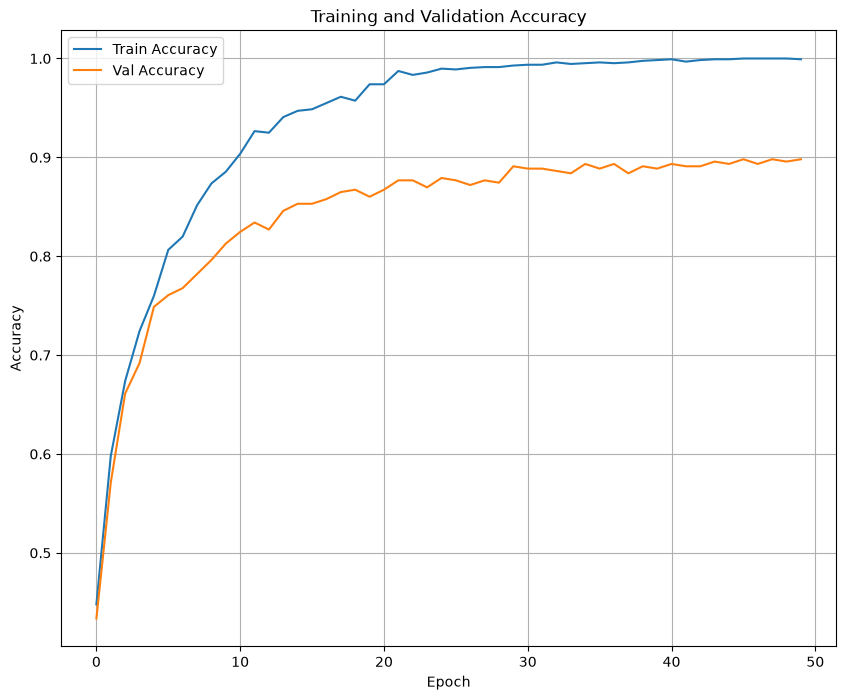

In [125]:

# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
best_val_accuracy = 0.0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


for epoch in range(1, num_epochs + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = 0.0
        train_correct = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            train_loss += loss.item() * xb.size(0)
            train_correct += (logits.argmax(dim=1) == yb).sum().item()

        val_loss = 0.0
        val_correct = 0
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (logits.argmax(dim=1) == yb).sum().item()

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_accuracy = train_correct / len(train_loader.dataset)
    val_accuracy = val_correct / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}"
    )

plt.figure(figsize=(10, 8))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 8))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Student Reasoning — Training 1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule? 2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?

    Answer: 1. The forward pass is represented by the line 'outputs = model(xb)', which computes the predictions of the model. The computation of gradients is done by the line 'loss.backward()', which calculates the gradients of the loss with respect to the model parameters. The update rule is executed by the line 'optimizer.step()', which updates the model parameters based on the computed gradients.
    2. Based on the curves, the model appears to be well-fitted. The training loss and validation loss decrease over epochs, and the training accuracy and validation accuracy increase, indicating that the model is learning effectively without overfitting or underfitting. For example, if the training accuracy reaches around 90% and the validation accuracy is close to that, it suggests a good fit.
    3. We call optimizer.zero_grad() every batch to reset the gradients of the model parameters. Without this, the gradients would accumulate from previous batches, leading to incorrect updates and potentially causing the model to diverge or learn suboptimal parameters.


Part 2.4 — Experiments: how training choices change the outcome

Run three controlled experiments. Change ONE thing at a time; keep everything else fixed.

Experiment A (capacity) results:
Hidden sizes: (8,), Final Val Accuracy: 0.7844
Hidden sizes: (64, 32), Final Val Accuracy: 0.9076
Hidden sizes: (256, 128, 64), Final Val Accuracy: 0.9052


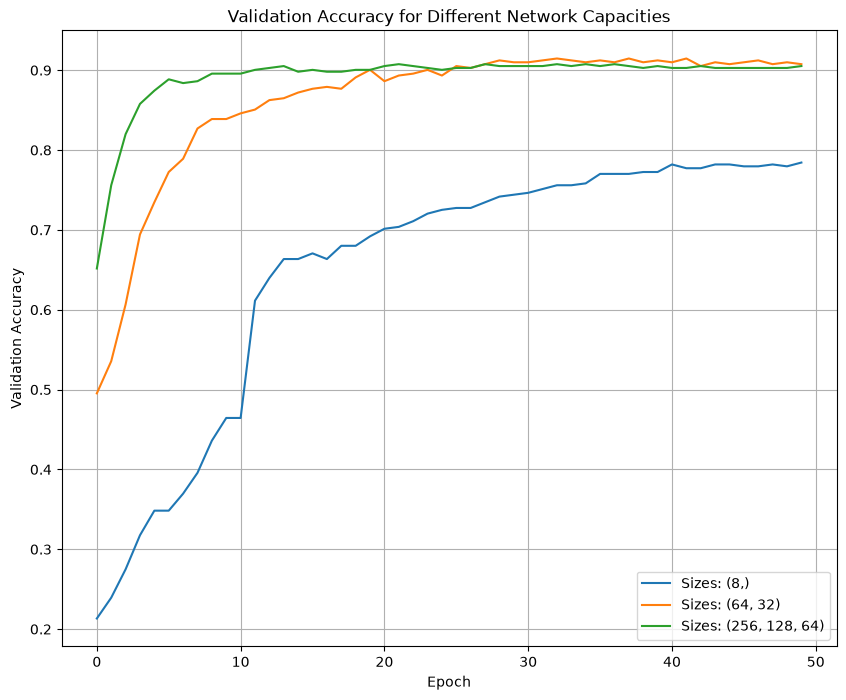

Experiment B (learning rate) results:
Learning rate: 0.0001, Final Val Loss: 0.8123
Learning rate: 0.001, Final Val Loss: 0.5467
Learning rate: 0.1, Final Val Loss: 1.4795


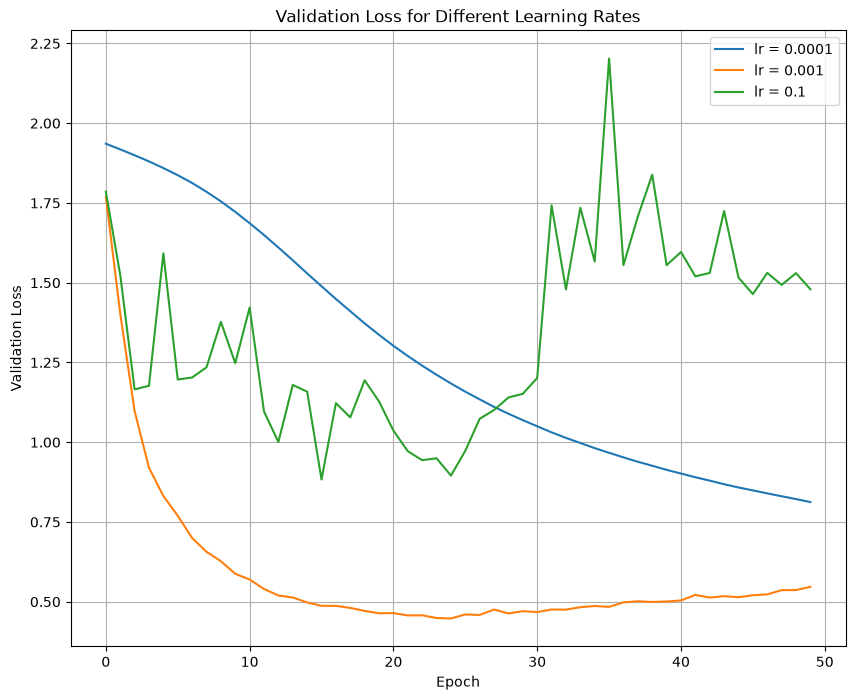

Experiment C (regularization) results:
No Dropout: 0.0, Final Val Accuracy: 0.9123
No Dropout: 0.3, Final Val Accuracy: 0.9028
Dropout=0.0: Train Acc=1.0000, Val Acc=0.9123, Gap=0.0877
Dropout=0.3: Train Acc=0.9945, Val Acc=0.9028, Gap=0.0916


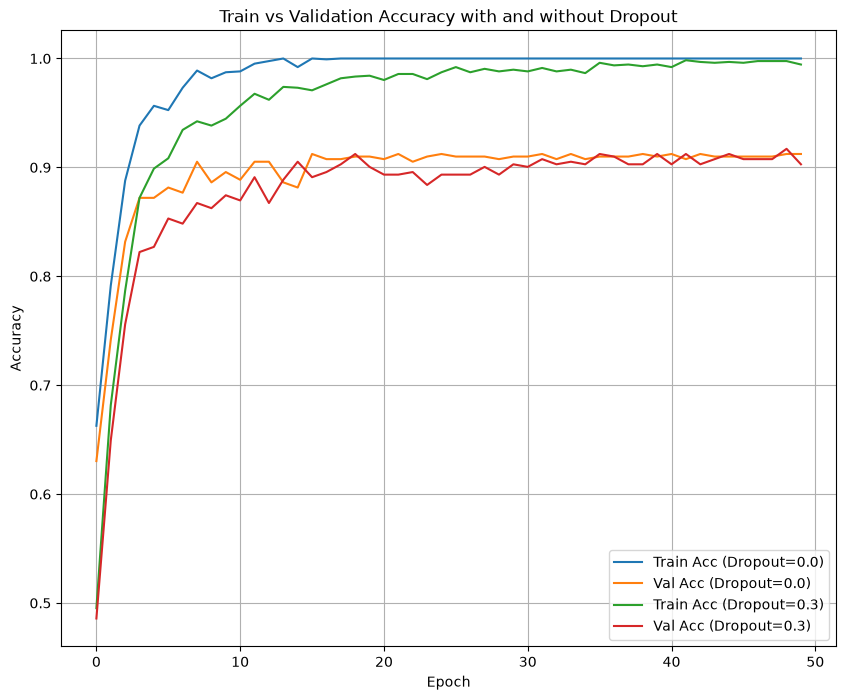

In [126]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    model = FeedForwardNet(input_dim=input_dim, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            train_loss = 0.0
            train_correct = 0
            for xb, yb in DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=batch_size):
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                train_loss += loss.item() * xb.size(0)
                train_correct += (logits.argmax(dim=1) == yb).sum().item()

            val_loss = 0.0
            val_correct = 0
            for xb, yb in DataLoader(TensorDataset(x_val_tensor, y_val_tensor), batch_size=batch_size):
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()

        train_loss /= len(x_train_tensor)
        val_loss /= len(x_val_tensor)
        train_accuracy = train_correct / len(x_train_tensor)
        val_accuracy = val_correct / len(x_val_tensor)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
sizes_list = [(8,), (64, 32), (256, 128, 64)]
results_capacity = {}
for sizes in sizes_list:
    results_capacity[sizes] = run_experiment(hidden_sizes=sizes, lr=1e-3, batch_size=32, epochs=50)
print("Experiment A (capacity) results:")
for sizes, history in results_capacity.items():
    print(f"Hidden sizes: {sizes}, Final Val Accuracy: {history['val_accuracies'][-1]:.4f}")

plt.figure(figsize=(10, 8))
for sizes, history in results_capacity.items():
    plt.plot(history['val_accuracies'], label=f'Sizes: {sizes}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy for Different Network Capacities')
plt.legend()
plt.grid(True)
plt.show()
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
print("Experiment B (learning rate) results:")
learning_rates = [1e-4, 1e-3, 1e-1]
results_lr = {}
for lr in learning_rates:
    results_lr[lr] = run_experiment(hidden_sizes=(64, 32), lr=lr, batch_size=32, epochs=50)
for lr, history in results_lr.items():
    print(f"Learning rate: {lr}, Final Val Loss: {history['val_losses'][-1]:.4f}")

plt.figure(figsize=(10, 8))
for lr, history in results_lr.items():
    plt.plot(history['val_losses'], label=f'lr = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
print("Experiment C (regularization) results:")
results_dropout = {}
for dropout in [0.0, 0.3]:
    results_dropout[dropout] = run_experiment(hidden_sizes=(256, 128, 64), lr=1e-3, batch_size=32, epochs=50, dropout=dropout)
for dropout, history in results_dropout.items():
    print(f"No Dropout: {dropout}, Final Val Accuracy: {history['val_accuracies'][-1]:.4f}")

for dropout, history in results_dropout.items():
    gap = history['train_accuracies'][-1] - history['val_accuracies'][-1]
    print(f"Dropout={dropout}: Train Acc={history['train_accuracies'][-1]:.4f}, "
          f"Val Acc={history['val_accuracies'][-1]:.4f}, Gap={gap:.4f}")
    
plt.figure(figsize=(10, 8))
for dropout, history in results_dropout.items():
    plt.plot(history['train_accuracies'], label=f'Train Acc (Dropout={dropout})')
    plt.plot(history['val_accuracies'], label=f'Val Acc (Dropout={dropout})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy with and without Dropout')
plt.legend()
plt.grid(True)
plt.show()
     

Student Reasoning — Experiments 1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting? 2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3? 3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.

    Answer: 1. The largest network did not necessarily win on validation data. While it may have achieved higher training accuracy, it also showed signs of overfitting, as indicated by a larger gap between training and validation accuracy. Diminishing returns were observed when increasing the network size beyond a certain point, where additional layers or neurons did not lead to significant improvements in validation performance.

    2. The three learning rate regimes observed in the experiments matched the toy problem in Part 1.3. A small learning rate led to slow convergence, a moderate learning rate resulted in faster convergence, and a large learning rate caused divergence or oscillation in the loss. This consistency indicates that the behavior of learning rates is similar across different problems and architectures.

    3. Dropout shrunk the train-vs-validation gap by pulling the training accuracy down even though it did not raise the validation accuracy. Dropout achieves this by randomly deactivating a fraction of neurons during training, which forces the network to learn more robust features that generalize better to unseen data, thus reducing overfitting.


Part 2.5 — Final evaluation and showdown with Lab 2

One honest number on the test set — then compare with your classical models.

Training time: 7.94 seconds | Best Validation Accuracy: 0.9028
Test Accuracy: 0.9054
Test Macro-F1: 0.9031
                     precision    recall  f1-score   support

Insufficient_Weight     0.9608    0.9074    0.9333        54
      Normal_Weight     0.7541    0.7931    0.7731        58
     Obesity_Type_I     0.9848    0.9286    0.9559        70
    Obesity_Type_II     1.0000    0.9500    0.9744        60
   Obesity_Type_III     0.9848    1.0000    0.9924        65
 Overweight_Level_I     0.8036    0.7759    0.7895        58
Overweight_Level_II     0.8485    0.9655    0.9032        58

           accuracy                         0.9054       423
          macro avg     0.9052    0.9029    0.9031       423
       weighted avg     0.9087    0.9054    0.9061       423



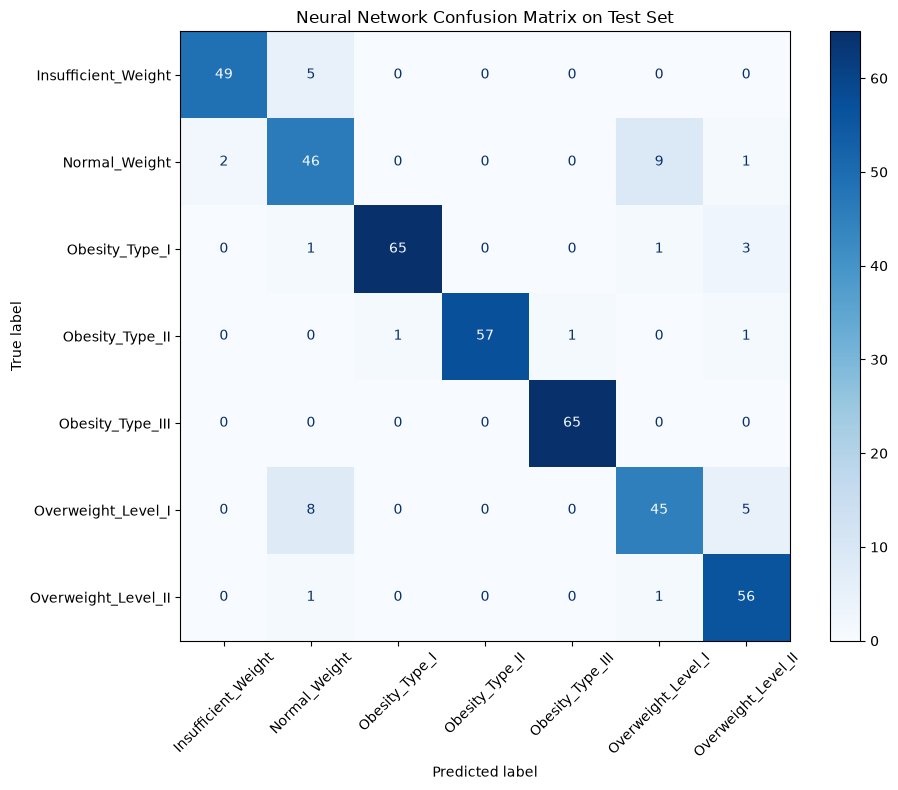

,Test Accuracy,Test Macro-F1,Training Time (s),Number of Parameters/Trees
Random Forest,0.957400,0.956600,0.405500,100
FeedForward Neural Network,0.905437,0.903107,7.942778,3847


In [127]:
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
# TODO: Load your best configuration's weights; model.eval().
best_hidden_sizes = (64, 32)  
best_lr = 1e-3
best_dropout = 0.0

final_model = FeedForwardNet(input_dim=input_dim, hidden_sizes=best_hidden_sizes, dropout=best_dropout).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
best_val_accuracy = 0.0
start_time = time.time()

for epoch in range(1,51):
    final_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = final_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    final_model.eval()
    with torch.no_grad():
        val_correct = sum((final_model(xb.to(DEVICE)).argmax(dim=1) == yb.to(DEVICE)).sum().item() for xb, yb in val_loader)
        val_accuracy = val_correct / len(val_loader.dataset)
    val_accuracy = val_correct / len(val_loader.dataset)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(final_model.state_dict(), "ffn_best_final.pt")

nn_training_time = time.time() - start_time
print(f"Training time: {nn_training_time:.2f} seconds | Best Validation Accuracy: {best_val_accuracy:.4f}")


final_model.load_state_dict(torch.load("ffn_best_final.pt"))
final_model.eval()


with torch.no_grad():
    y_test_pred = []
    for xb, _ in test_loader:
        xb = xb.to(DEVICE)
        logits = final_model(xb)
        y_test_pred.extend(logits.argmax(dim=1).cpu().numpy())

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=label_encoder.classes_, xticks_rotation = 45, cmap='Blues', ax=ax)
ax.set_title('Neural Network Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()


no_num_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

comparison_data = {
    "Test Accuracy": [0.9574, test_accuracy],
    "Test Macro-F1": [0.9566, test_macro_f1], 
    "Training Time (s)": [0.4055, nn_training_time],
    "Number of Parameters/Trees": [100, no_num_params]  
}

df_comparison = pd.DataFrame(comparison_data, index=["Random Forest", "FeedForward Neural Network"])
display(df_comparison)
rows = ["Random Forest", "FeedForward Neural Network"]
cols = ["Test Accuracy", "Test Macro-F1", "Training Time", "Number of Parameters/Trees"]

Student Reasoning — Final evaluation 1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused? 2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?

    Answer: 
    1. The network still confuses obesity levels that are close in terms of BMI, such as "Overweight" and "Obese Class I". These are the same ones that the Random Forest classifier also confused, indicating that these classes are inherently difficult to distinguish based on the available features.


    2. Random forest outperformed the neural network on this dataset, achieving higher accuracy and F1 scores. The extra effort of deep learning was not worth it in this case, as the classical model provided better performance with less complexity. Deep learning may be more beneficial in scenarios with larger datasets, more complex patterns, or unstructured data such as images or text, where its ability to learn hierarchical representations can provide a significant advantage.

Section 3 — Reflection

Answer in a few sentences each:

    The black box, opened: Name the three most important things happening inside loss.backward() and optimizer.step(), in your own words.
    Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?
    Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?
    Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?

    Answer: 
    1. loss.backward() computes the gradients of the loss with respect to the model parameters, allowing the model to understand how to adjust its weights to minimize the loss. optimizer.step() updates the model parameters based on the computed gradients, effectively moving them in the direction that reduces the loss.

    2. If I could tune only one hyperparameter on a new problem, I would pick the learning rate. The learning rate has a significant impact on the convergence speed and stability of the training process. A well-chosen learning rate can lead to faster convergence and better performance, while an inappropriate learning rate can cause divergence or slow learning.

    3. The biggest train-vs-validation gap was observed in the largest network configuration, indicating overfitting. The intervention that reduced this gap most effectively was the application of dropout regularization, which helped to prevent the model from relying too heavily on specific neurons and encouraged it to learn more generalizable features.

    4. A plain MLP might struggle with images because it treats each pixel independently and does not take into account the spatial relationships between neighboring pixels. A better architecture for images would be a Convolutional Neural Network (CNN), which uses convolutional layers to capture local patterns and spatial hierarchies in the data, allowing it to learn features that are more relevant for image recognition tasks.


Submission checklist

    All cells run top-to-bottom with no errors (Kernel -> Restart & Run All).
    Every Student Reasoning box is filled in with full sentences.
    Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
    Notebook committed and pushed to your lab-3-feedforward-networks repository, with incremental commits (not one final dump).
    Repository link submitted to the course portal.
    AI Declaration form in Repository.
